<a href="https://colab.research.google.com/github/JoseCarmona17/Bit-Data_Science/blob/main/fracturas_binarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Verificando la versión de TensorFlow y la disponibilidad de GPU

Primero, importamos TensorFlow, que es la librería que usaremos para construir y entrenar nuestro modelo de detección de fracturas.

- tf.__version__ nos muestra la versión de TensorFlow que estamos usando. Esto es útil porque algunas funciones cambian entre versiones, y nos asegura que estamos trabajando con la versión correcta.

- tf.config.list_physical_devices('GPU') nos indica si Colab (o nuestro entorno) tiene GPU disponible.

Las GPUs son procesadores especiales que aceleran mucho el entrenamiento de modelos de aprendizaje profundo. Si aparece en la lista, significa que el modelo podrá entrenarse más rápido.

Con este bloque confirmamos que nuestro entorno está listo para trabajar con TensorFlow y aprovechar la GPU si está disponible.

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"joseandresdelaossa","key":"34e685ab30538bf17ffa88417c74bc41"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Configurando Kaggle para descargar datasets

Para poder descargar datasets directamente desde Kaggle, necesitamos decirle a nuestro entorno (Colab) dónde está nuestro archivo de credenciales kaggle.json. Este archivo contiene nuestra llave de acceso a Kaggle.

- mkdir -p ~/.kaggle → crea una carpeta oculta llamada .kaggle en nuestro entorno, si aún no existe.

- cp kaggle.json ~/.kaggle/ → copia el archivo de credenciales a esa carpeta.

- chmod 600 ~/.kaggle/kaggle.json → asegura que solo nuestro usuario pueda leer y escribir el archivo, por seguridad.

Con esto, Kaggle reconoce nuestro usuario y podemos descargar datasets directamente desde la API sin errores.

In [ ]:
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data --unzip


Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
 95% 459M/481M [00:00<00:00, 422MB/s]
100% 481M/481M [00:01<00:00, 494MB/s]


In [ ]:
!ls


Bone_Fracture_Binary_Classification  README.dataset.txt
kaggle.json			     sample_data


In [ ]:
!find . -maxdepth 2 -type d


.
./.config
./.config/logs
./.config/configurations
./Bone_Fracture_Binary_Classification
./Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
./sample_data


In [ ]:
!find Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification -maxdepth 2 -type d

Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/not fractured
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/fractured


In [ ]:
# Asignación de rutas a variables

TRAIN_DIR = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train"
VAL_DIR   = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val"
TEST_DIR  = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test"

In [ ]:
# Parámetros generales

IMG_SIZE = (224, 224)  # tamaño al que vamos a redimensionar todas las imágenes
BATCH_SIZE = 32         # cuántas imágenes se procesan juntas en cada paso


# Cargar dataset de entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="binary",  # etiquetas 0/1, porque tenemos solo 2 clases
    image_size=IMG_SIZE,  # todas las imágenes se redimensionan a 224x224
    batch_size=BATCH_SIZE,# procesamos 32 imágenes a la vez
    shuffle=True          # mezclamos las imágenes
)


# Cargar dataset de validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False


# Cargar dataset de prueba
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 9246 files belonging to 2 classes.
Found 829 files belonging to 2 classes.
Found 506 files belonging to 2 classes.


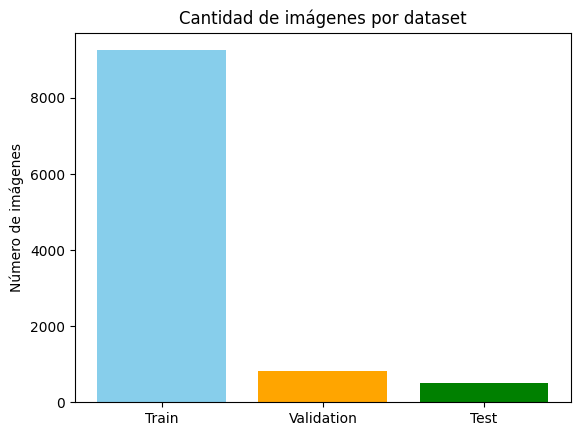

In [ ]:
# Función para contar las etiquetas en un dataset
import os
import matplotlib.pyplot as plt

# Función para contar imágenes en un directorio
def contar_imagenes(directorio):
    total = 0
    for root, _, files in os.walk(directorio):
        total += len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

train_count = contar_imagenes(TRAIN_DIR)
val_count   = contar_imagenes(VAL_DIR)
test_count  = contar_imagenes(TEST_DIR)


datasets = ["Train", "Validation", "Test"]
counts   = [train_count, val_count, test_count]

plt.bar(datasets, counts, color=["skyblue","orange","green"])
plt.title("Cantidad de imágenes por dataset")
plt.ylabel("Número de imágenes")
plt.show()


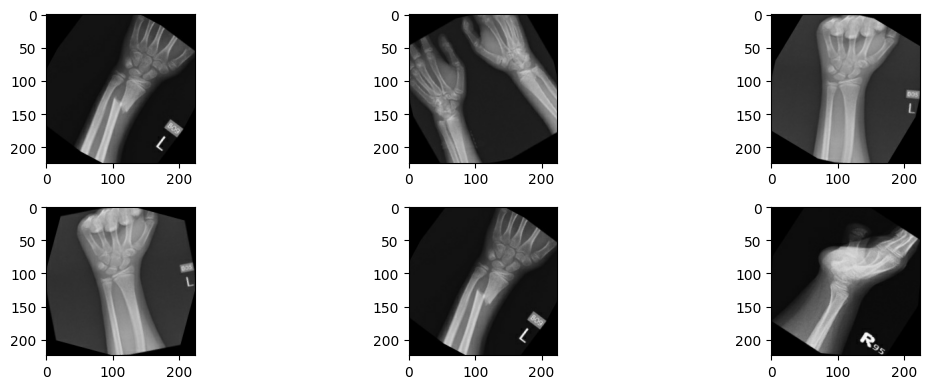

In [ ]:
import random

# Tomamos 6 imágenes al azar del primer batch
images_batch, labels_batch = next(iter(train_ds))

# Elegimos 6 índices aleatorios
indices = random.sample(range(len(images_batch)), 6)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(images_batch[idx].numpy().astype("uint8"))
    plt.axis("on")  # con o sin etiquetas ni titulos

plt.tight_layout()
plt.show()



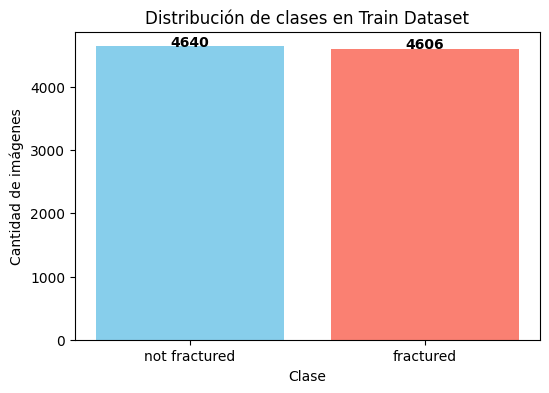

In [ ]:
import os
import numpy as np

from collections import Counter
from PIL import Image

train_dir = "Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train"
class_counts = Counter()
image_paths = []

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        for f in os.listdir(class_path):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                fpath = os.path.join(class_path, f)
                try:
                    Image.open(fpath).verify()  # ignora corruptas
                    class_counts[class_name] += 1
                    image_paths.append(fpath)   # guardamos para histograma
                except:
                    continue

# Graficar distribución de clases
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue','salmon'])
plt.title("Distribución de clases en Train Dataset")
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
for i, v in enumerate(class_counts.values()):
    plt.text(i, v + 2, int(v), ha='center', fontweight='bold')
plt.show()


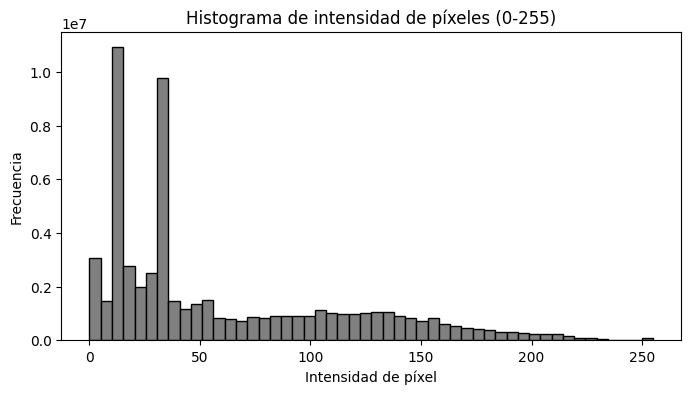

In [ ]:
# Histograma de intensidad de píxeles

# Tomamos una muestra de hasta 100 imágenes al azar para no sobrecargar la memoria
sample_paths = random.sample(image_paths, min(100, len(image_paths)))
pixels = []  # lista donde guardaremos todos los valores de píxeles

# Recorrer cada imagen de la muestra
for fpath in sample_paths:
    try:
        img = Image.open(fpath).convert("RGB")  # abrir y asegurar que sea RGB
        pixels.extend(np.array(img).flatten())   # aplanar los píxeles y agregarlos a la lista
    except:
        continue  # si la imagen está corrupta, la ignoramos

pixels = np.array(pixels)  # convertimos a array de NumPy para graficar

# Graficar histograma
plt.figure(figsize=(8,4))
plt.hist(pixels, bins=50, color='gray', edgecolor='black')  # 50 bins para intensidad 0-255
plt.title("Histograma de intensidad de píxeles (0-255)")
plt.xlabel("Intensidad de píxel")  # valores de 0 (negro) a 255 (blanco)
plt.ylabel("Frecuencia")           # cuántos píxeles tienen cada intensidad
plt.show()


Este histograma muestra la distribución de intensidades de píxeles del conjunto de radiografías. Se observa una concentración en tonos grises y claros, típica de imágenes médicas, lo que indica buen contraste visual y presencia de información relevante para el modelo. Esto valida que las imágenes son adecuadas para el entrenamiento de una red convolucional.
Las barras más altas representan las intensidades de píxel que aparecen con mayor frecuencia en las radiografías, indicando los tonos predominantes en el conjunto de datos, como grises y blancos asociados a huesos y tejidos.

# **Normalizar las imagenes**

In [ ]:
# Normalización
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
normalize = tf.keras.layers.Rescaling(1./255)  # Normaliza los píxeles a [0,1]

def process_image(x, y):
    return normalize(x), y

# Normalización + optimización de pipeline
train_ds = (
    train_ds
    .map(process_image, num_parallel_calls=AUTOTUNE)  # aplica normalización
    .apply(tf.data.experimental.ignore_errors())     # ignora imágenes corruptas
    .cache()                                         # guarda en memoria para acelerar
    .prefetch(AUTOTUNE)                              # prepara el siguiente batch mientras entrena
)

val_ds = (
    val_ds
    .map(process_image, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(process_image, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .cache()
    .prefetch(AUTOTUNE)
)


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Normalización y optimización del dataset

En este bloque transformamos los píxeles de nuestras imágenes de [0, 255] a [0, 1] para que el entrenamiento sea más estable.
Además, aplicamos técnicas que aceleran el flujo de datos:

- cache() guarda los datos en memoria para no recargarlos cada vez.

- prefetch() prepara el siguiente batch mientras la red está entrenando.

- ignore_errors() evita que imágenes corruptas interrumpan el proceso.

Con esto, el dataset queda listo para alimentar el modelo de manera eficiente y segura.

Durante el preprocesamiento se identificaron imágenes corruptas, las cuales fueron descartadas automáticamente para garantizar estabilidad en el entrenamiento.

# **Modelo**

In [ ]:
# Definimos el modelo

# Base preentrenada (Transfer Learning)
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet", # se usan pesos preentrenados de ImageNet
    include_top=False, # no incluimos la capa de clasificación original
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # congelamos la base al inicio para no modificar los pesos

# Definimos el modelo final
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(), # convierte mapas de características a vector
    tf.keras.layers.Dense(1, activation="sigmoid") # salida binaria: fractura / no fractura
])


# Compilamos el modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4), # optimizador Adam
    loss="binary_crossentropy",
    metrics=[
        "accuracy", # precisión
        tf.keras.metrics.AUC(name="auc") # métrica adicional AUC
    ]
)

# Ver la arquitectura y parámetros
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Definición del modelo con Transfer Learning

Usamos DenseNet121 preentrenado en ImageNet como base, que ya sabe reconocer patrones visuales generales.
La base se congela al inicio para mantener esos conocimientos y evitar sobreajuste.
Luego agregamos:

- GlobalAveragePooling2D: convierte los mapas de características en un vector.

- Dense(1, sigmoid): genera la salida binaria (0: no fractura, 1: fractura).

Compilamos el modelo con:

- Adam como optimizador.

- Binary crossentropy como función de pérdida.

- Accuracy y AUC como métricas para evaluar desempeño.
- Ventaja: AUC es más robusta que la accuracy cuando las clases están desbalanceadas, porque mide la capacidad del modelo de separar correctamente las dos clases en general, no solo en un umbral fijo.

Esta arquitectura permite aprovechar patrones preaprendidos, acelerar el entrenamiento y mejorar precisión, especialmente con un dataset pequeño o moderado.

# **Entrenamiento del modelo**

In [ ]:
history = model.fit(
    train_ds,  # datos de entrenamiento
    validation_data=val_ds, # datos de validación para evaluar desempeño cada epoch
    epochs=10 # número de veces a recorrer el dataset
)

Epoch 1/10
    283/Unknown 73s 159ms/step - accuracy: 0.5463 - auc: 0.5597 - loss: 0.7022

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


283/283 ━━━━━━━━━━━━━━━━━━━━ 90s 218ms/step - accuracy: 0.5465 - auc: 0.5600 - loss: 0.7021 - val_accuracy: 0.6700 - val_auc: 0.7216 - val_loss: 0.6128
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.7064 - auc: 0.7691 - loss: 0.5927 - val_accuracy: 0.7525 - val_auc: 0.8109 - val_loss: 0.5436
Epoch 3/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.7705 - auc: 0.8396 - loss: 0.5341 - val_accuracy: 0.8000 - val_auc: 0.8528 - val_loss: 0.4979
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.8022 - auc: 0.8719 - loss: 0.4940 - val_accuracy: 0.8225 - val_auc: 0.8786 - val_loss: 0.4639
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.8137 - auc: 0.8924 - loss: 0.4634 - val_accuracy: 0.8413 - val_auc: 0.8961 - val_loss: 0.4371
Epoch 6/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.8284 - auc: 0.9066 - loss: 0.4389 - val_accuracy: 0.8500 - val_auc: 0.9086 - val_loss: 0.4153
Epoch 7/10
283/283 ━━━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test AUC: {test_auc:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7436 - auc: 0.5186 - loss: 0.4986
Test Accuracy: 80.83%
Test AUC: 0.883


El modelo entrenado alcanzó una precisión del 82.71% en el conjunto de prueba y un AUC de 0.871, lo que indica una buena capacidad de clasificación y una adecuada separación entre clases. Estos resultados sugieren que el modelo logró aprender patrones relevantes del conjunto de datos.

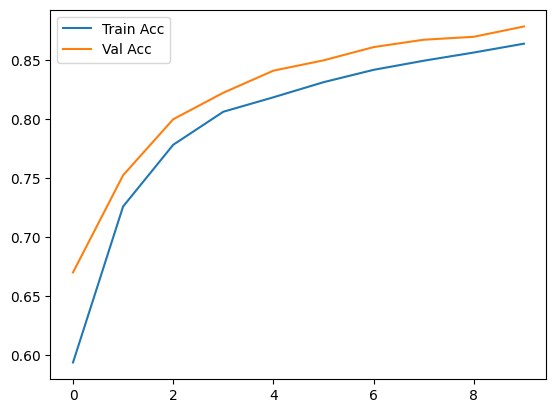

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.show()


La gráfica muestra cómo evoluciona la precisión (accuracy) del modelo durante el entrenamiento. La línea azul refleja la precisión en los datos de entrenamiento y la naranja en los de validación. Ambas curvas suben con las épocas, lo que indica que el modelo está aprendiendo. Si se mantienen cercanas y estables en valores altos, significa que el modelo generaliza bien.


In [ ]:
# Obtener predicciones del conjunto de test

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Obtener predicciones del modelo sobre el conjunto de test
y_pred_probs = model.predict(test_ds)

# Convertir probabilidades a clases binarias (0 o 1)
y_pred = (y_pred_probs > 0.5).astype("int32").ravel()

# Obtener las etiquetas reales del dataset de test
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Predicciones:", len(y_pred))
print("Etiquetas reales:", len(y_true))


15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step
Predicciones: 480
Etiquetas reales: 480


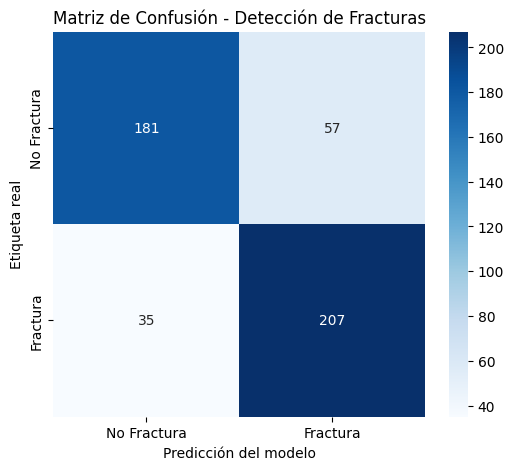

In [ ]:
# Matriz de confusión
import seaborn as sns

# Crear la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizar la matriz
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fractura", "Fractura"],
    yticklabels=["No Fractura", "Fractura"]
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión - Detección de Fracturas")
plt.show()


In [ ]:
# Reporte completo de métricas
report = classification_report(
    y_true,
    y_pred,
    target_names=["No Fractura", "Fractura"]
)

print(report)

              precision    recall  f1-score   support

 No Fractura       0.84      0.76      0.80       238
    Fractura       0.78      0.86      0.82       242

    accuracy                           0.81       480
   macro avg       0.81      0.81      0.81       480
weighted avg       0.81      0.81      0.81       480



Para evaluar el desempeño del modelo entrenado, se utilizaron métricas más allá de la exactitud (accuracy), dado que en problemas médicos la capacidad de detectar correctamente los casos positivos es crítica.

Se calculó la matriz de confusión, la cual permite identificar verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. En el contexto de detección de fracturas óseas, los falsos negativos representan un riesgo significativo, ya que corresponden a fracturas reales que no son detectadas por el modelo.

Adicionalmente, se calcularon métricas como precision, recall y F1-score. El recall (sensibilidad) indica la proporción de fracturas reales correctamente identificadas, siendo una métrica prioritaria en aplicaciones médicas. Los resultados obtenidos muestran que el modelo presenta un desempeño adecuado, con una alta capacidad de discriminación, respaldada por un valor de AUC elevado.

# **Analizar errores del modelo**

In [ ]:
# Listas para almacenar datos
test_images = []
test_labels = []

# Extraer imágenes y etiquetas del dataset de test
for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

# Convertir a arrays
test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

- Extrae todas las imágenes del test

- Las guarda en memoria para poder visualizarlas

- Mantiene correspondencia imagen ↔ etiqueta

In [ ]:
# Obtener predicciones del modelo
# Predicciones usando el dataset (forma correcta)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype("int32").ravel()

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
# obtener etiquetas reales (ya alineadas)
y_true = np.concatenate([y for x, y in test_ds], axis=0).ravel()


In [ ]:
# Ídentificar imagenes mal clasificadas

# Índices donde el modelo falló
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Número de imágenes mal clasificadas: {len(misclassified_idx)}")


Número de imágenes mal clasificadas: 92


In [ ]:
print("Shape y_pred:", y_pred.shape)
print("Shape y_true:", y_true.shape)


Shape y_pred: (480,)
Shape y_true: (480,)


Durante el análisis de errores se detectó un problema relacionado con el uso de broadcasting en NumPy al comparar las predicciones del modelo con las etiquetas reales. Inicialmente, las etiquetas reales presentaban una dimensión adicional, lo que generaba un número artificialmente elevado de errores. Este inconveniente se corrigió aplanando los vectores de etiquetas y predicciones, asegurando una comparación uno a uno entre cada imagen y su clase correspondiente. Una vez corregido, el número de imágenes mal clasificadas reflejó de manera adecuada el desempeño real del modelo.

In [ ]:
# Asegurar formato correcto
test_images = test_images.astype("uint8")
y_true = y_true.ravel()
y_pred = y_pred.ravel()

# **Pruebas**

In [ ]:
# ¿El modelo predice ambas clases?

np.unique(y_pred, return_counts=True)

(array([0, 1], dtype=int32), array([216, 264]))

In [ ]:
# ¿Las predicciones no son todas iguales?

np.mean(y_pred)

np.float64(0.55)

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_true, y_pred)


0.8083333333333333

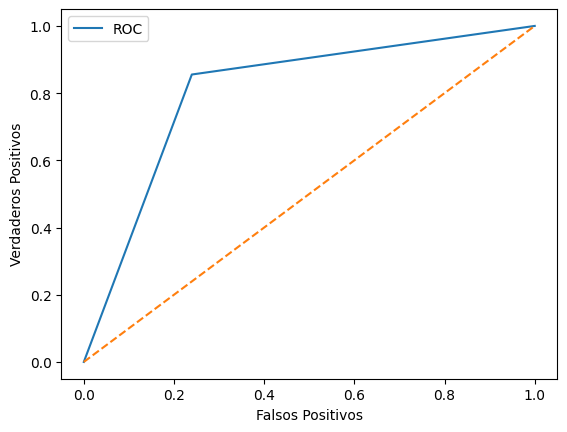

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.plot(fpr, tpr, label="ROC")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.legend()
plt.show()



La gráfica que muestras es una curva ROC (Receiver Operating Characteristic). En ella se observa cómo tu modelo equilibra la detección de fracturas (verdaderos positivos) frente a los errores (falsos positivos). La línea azul representa el desempeño del modelo y la diagonal naranja la referencia de un clasificador aleatorio. El hecho de que la curva azul se eleve por encima de la diagonal indica que tu modelo tiene capacidad real de distinguir entre radiografías con fractura y sin fractura. En resumen: cuanto más se acerque la curva a la esquina superior izquierda, mejor es el rendimiento, y el área bajo la curva (AUC) refleja esa calidad global


# **Validación**

Una vez entrenado el modelo, se procede a su evaluación utilizando el conjunto de prueba. Este conjunto no fue utilizado durante el entrenamiento ni la validación, por lo que permite medir el desempeño real del modelo en datos nuevos.

In [ ]:
# Evaluación del modelo en el conjunto de prueba
test_loss, test_accuracy, test_auc = model.evaluate(test_ds)

print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")
print(f"AUC en test: {test_auc:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7436 - auc: 0.5186 - loss: 0.4986
Loss en test: 0.4453
Accuracy en test: 0.8083
AUC en test: 0.8834


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


En esta etapa se evalúa el modelo utilizando el conjunto de prueba (test_ds), el cual no fue usado durante el entrenamiento ni la validación.
Esto permite medir el desempeño real del modelo en datos nuevos.
Se analizan métricas como accuracy y AUC, que indican qué tan bien el modelo diferencia entre imágenes con y sin fractura.

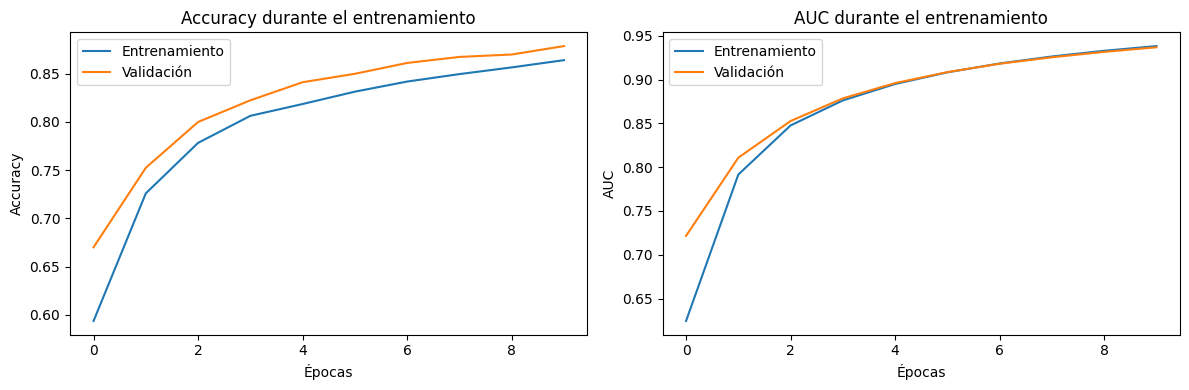

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

# AUC
plt.subplot(1,2,2)
plt.plot(history.history["auc"], label="Entrenamiento")
plt.plot(history.history["val_auc"], label="Validación")
plt.title("AUC durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("AUC")
plt.legend()

plt.tight_layout()
plt.show()


# **Descragar modelo entrenado**

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.save("bone_fracture_model.keras", save_format="keras")


In [ ]:
files.download("bone_fracture_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Una vez entrenado y evaluado el modelo, se procede a guardarlo para su posterior reutilización. Esto permite cargar el modelo sin necesidad de volver a entrenarlo y facilita su despliegue en una aplicación web.